# CV v2 Diagnostics (temporary)

`CV_Results_v2/cv_stats.csv` + `cv_zscores.pkl` 기반 normative-v2 엔진 적합도(calibration) 점검용 임시 노트북.

In [1]:
import pickle
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm

import config
from viz_style import apply_style
apply_style()

CV_DIR = config.CV_RESULTS_DIR_V2
PALETTE = {'nbi': '#E41A1C', 'nb_fixed': '#377EB8', 'intercept': '#4DAF4A', 'pool': '#984EA3'}
STAGE_ORDER = ['nbi', 'nb_fixed', 'intercept', 'pool']

df = pd.read_csv(CV_DIR / 'cv_stats.csv')
df['stage_key'] = np.where(df['route'] == 'pool', 'pool', df['stage'])
with open(CV_DIR / 'cv_zscores.pkl', 'rb') as f:
    zdict = pickle.load(f)

print(f'genes: {len(df):,}')
df['stage_key'].value_counts().reindex(STAGE_ORDER)

genes: 20


stage_key
nbi          20.0
nb_fixed      NaN
intercept     NaN
pool          NaN
Name: count, dtype: float64

## Summary table by stage
`w1` = held-out RQR z와 이론적 N(0,1) 분위수 간 평균 절대편차(0에 가까울수록 정규분포에 가까움). `mean_z`~0, `std_z`~1 이 이상적.

In [2]:
summary = df.groupby('stage_key')[['w1', 'mean_z', 'std_z', 'skew_z', 'kurt_z', 'n_valid']].median()
summary['n_genes'] = df['stage_key'].value_counts()
summary.reindex(STAGE_ORDER)

,w1,mean_z,std_z,skew_z,kurt_z,n_valid,n_genes
stage_key,,,,,,,
nbi,0.059573,0.007918,1.060407,-0.089537,0.713038,693.0,20.0
nb_fixed,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intercept,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pool,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Per-stage metric distributions

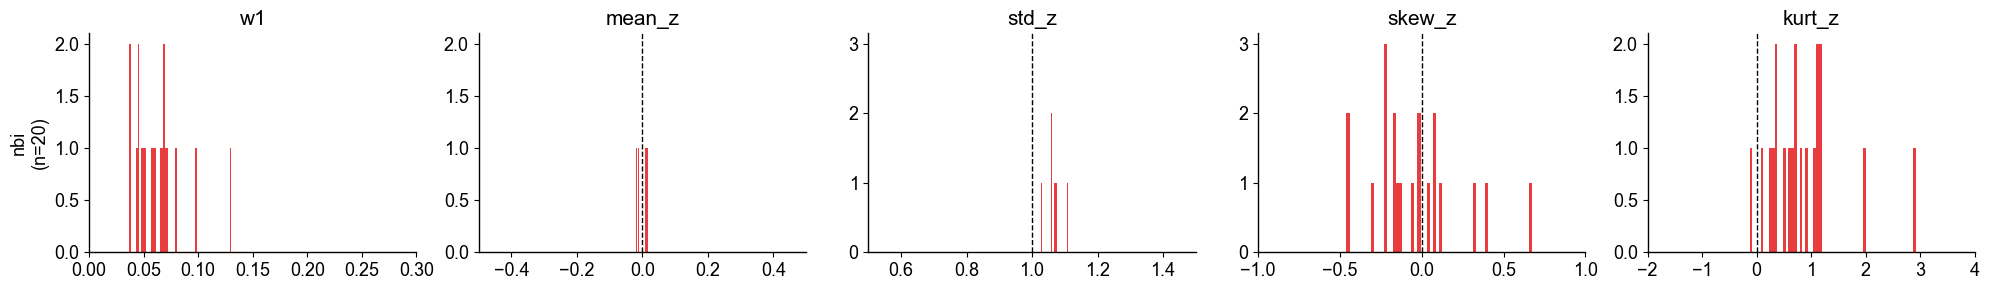

In [3]:
metrics = [('w1', (0, 0.3)), ('mean_z', (-0.5, 0.5)), ('std_z', (0.5, 1.5)),
           ('skew_z', (-1, 1)), ('kurt_z', (-2, 4))]
stages_present = [s for s in STAGE_ORDER if s in df['stage_key'].unique()]

fig, axes = plt.subplots(len(stages_present), len(metrics),
                          figsize=(4 * len(metrics), 3 * len(stages_present)), squeeze=False)
for r, stage in enumerate(stages_present):
    sub = df[df['stage_key'] == stage]
    for c, (col, xlim) in enumerate(metrics):
        ax = axes[r, c]
        v = sub[col].clip(*xlim)
        ax.hist(v, bins=60, color=PALETTE[stage], alpha=0.85)
        target = 0.0 if col != 'std_z' else 1.0
        if col == 'w1':
            target = None
        if target is not None:
            ax.axvline(target, color='black', lw=1, ls='--')
        ax.set_xlim(xlim)
        if r == 0:
            ax.set_title(col)
        if c == 0:
            ax.set_ylabel(f'{stage}\n(n={len(sub):,})')
fig.tight_layout()

## mean_z vs std_z joint calibration

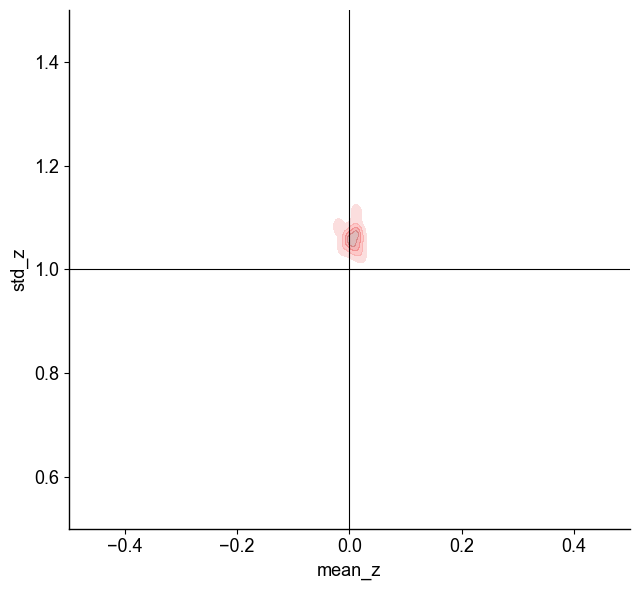

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 6))
xlim, ylim = (-0.5, 0.5), (0.5, 1.5)
for stage in stages_present:
    sub = df[df['stage_key'] == stage].dropna(subset=['mean_z', 'std_z'])
    mz = sub['mean_z'].clip(*xlim)
    sz = sub['std_z'].clip(*ylim)
    sns.kdeplot(x=mz, y=sz, ax=ax, label=stage, color=PALETTE[stage],
                levels=5, fill=True, alpha=0.35, linewidths=1.2)
ax.axvline(0, color='black', lw=0.8)
ax.axhline(1, color='black', lw=0.8)
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_xlabel('mean_z'); ax.set_ylabel('std_z')
ax.legend(frameon=False)
fig.tight_layout()

## Calibration (W1) vs NZ (detection rate proxy)
nz가 낮은 유전자일수록 (특히 nbi/nb_fixed 강등 근처) 적합도가 나빠지는지 확인.

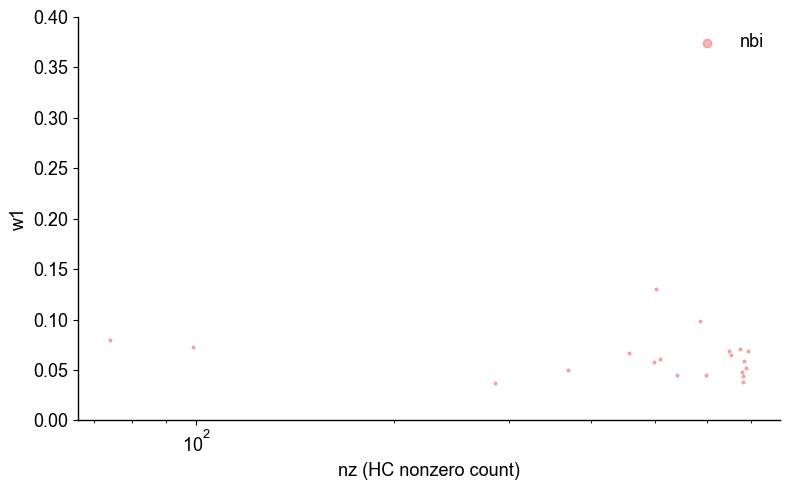

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for stage in stages_present:
    sub = df[df['stage_key'] == stage]
    ax.scatter(sub['nz'], sub['w1'], s=4, alpha=0.3, color=PALETTE[stage], label=stage)
ax.set_xscale('log')
ax.set_xlabel('nz (HC nonzero count)'); ax.set_ylabel('w1')
ax.set_ylim(0, 0.4)
ax.legend(frameon=False, markerscale=3)
fig.tight_layout()

## Worst-calibrated genes (top W1)

In [6]:
worst = df.sort_values('w1', ascending=False).head(20)[
    ['gene', 'stage_key', 'nz', 'w1', 'mean_z', 'std_z', 'skew_z', 'kurt_z', 'n_valid']]
worst

,gene,stage_key,nz,w1,mean_z,std_z,skew_z,kurt_z,n_valid
17,ENSG00000001630.19,nbi,502,0.130277,0.013595,1.074383,-0.457416,0.260654,693
7,ENSG00000001036.15,nbi,586,0.098659,0.009161,1.076216,-0.216908,1.149064,693
1,ENSG00000000005.6,nbi,74,0.080085,0.012731,1.108836,0.671938,2.921961,693
15,ENSG00000001626.19,nbi,99,0.072452,-0.018573,1.081475,0.399760,1.971798,693
2,ENSG00000000419.15,nbi,673,0.070544,0.015584,1.069109,-0.228793,0.897876,693
5,ENSG00000000938.14,nbi,693,0.068601,0.015819,1.047904,-0.228446,0.598744,693
3,ENSG00000000457.15,nbi,648,0.068390,0.013731,1.071671,-0.289951,1.045339,693
19,ENSG00000002016.19,nbi,457,0.067097,0.016333,1.047905,-0.048960,-0.130719,693
11,ENSG00000001461.20,nbi,653,0.065030,0.002766,1.058762,-0.171802,1.177129,693
13,ENSG00000001561.8,nbi,509,0.060360,0.010587,1.039178,-0.154034,0.280172,693


## QQ example: best vs worst calibrated gene per stage

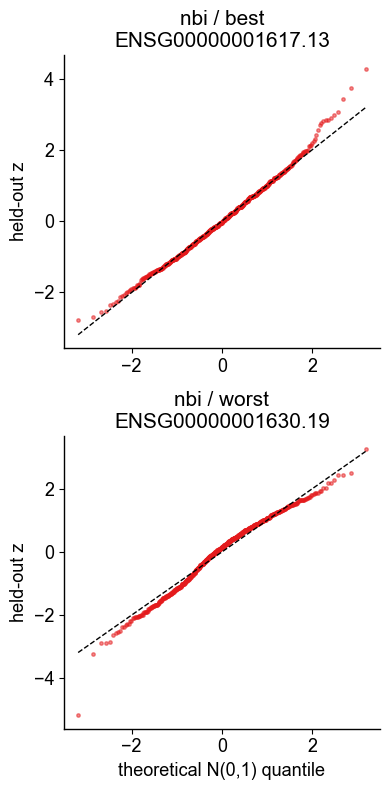

In [7]:
fig, axes = plt.subplots(2, len(stages_present), figsize=(4 * len(stages_present), 8), squeeze=False)
for c, stage in enumerate(stages_present):
    sub = df[df['stage_key'] == stage].dropna(subset=['w1'])
    best_gene = sub.loc[sub['w1'].idxmin(), 'gene']
    worst_gene = sub.loc[sub['w1'].idxmax(), 'gene']
    for r, (gene, label) in enumerate([(best_gene, 'best'), (worst_gene, 'worst')]):
        ax = axes[r, c]
        z = zdict[gene]
        z = z[np.isfinite(z)]
        n = len(z)
        ref = norm.ppf(np.linspace(1 / (2 * n), 1 - 1 / (2 * n), n))
        ax.scatter(ref, np.sort(z), s=6, alpha=0.5, color=PALETTE[stage])
        lo, hi = ref.min(), ref.max()
        ax.plot([lo, hi], [lo, hi], color='black', lw=1, ls='--')
        ax.set_title(f'{stage} / {label}\n{gene}')
        if r == 1:
            ax.set_xlabel('theoretical N(0,1) quantile')
        if c == 0:
            ax.set_ylabel('held-out z')
fig.tight_layout()

## Pooled z histogram by stage (all held-out folds combined)

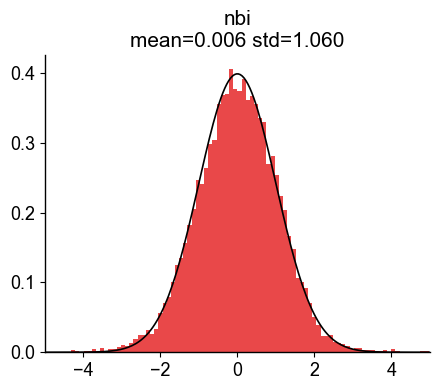

In [8]:
fig, axes = plt.subplots(1, len(stages_present), figsize=(4.5 * len(stages_present), 4), squeeze=False)
xs = np.linspace(-5, 5, 200)
for c, stage in enumerate(stages_present):
    genes = df.loc[df['stage_key'] == stage, 'gene']
    z_all = np.concatenate([zdict[g][np.isfinite(zdict[g])] for g in genes])
    ax = axes[0, c]
    ax.hist(z_all, bins=100, density=True, color=PALETTE[stage], alpha=0.8)
    ax.plot(xs, norm.pdf(xs), color='black', lw=1.2)
    ax.set_title(f'{stage}\nmean={z_all.mean():.3f} std={z_all.std():.3f}')
    ax.set_xlim(-5, 5)
fig.tight_layout()